In [ ]:
#[Problem 1] Function for finding impureness

In [1]:
import numpy as np

def calculate_gini_impurity(y_node):
    """
    Calculates the Gini Impurity for a set of samples (node).

    Parameters
    ----------
    y_node : ndarray, shape (n_samples,)
        The class labels for the samples in the node.

    Returns
    -------
    gini_impurity : float
        The calculated Gini Impurity value.
    """
    # Total number of samples in the node
    n_total = len(y_node)

    # If there are no samples, impurity is 0
    if n_total == 0:
        return 0.0

    # Get unique class labels and their counts
    unique_classes, counts = np.unique(y_node, return_counts=True)

    # Calculate the probability of each class
    # p_i = N_t,i / N_t,all
    probabilities = counts / n_total

    # Calculate the sum of squared probabilities
    # sum(p_i^2)
    sum_of_squares = np.sum(probabilities**2)

    # Calculate Gini Impurity: I(t) = 1 - sum(p_i^2)
    gini_impurity = 1.0 - sum_of_squares

    return gini_impurity

In [ ]:
#[Problem 2] Function for finding information gain

In [2]:
def calculate_information_gain(y_parent, y_left, y_right):
    """
    Calculates the Information Gain for a split.

    Parameters
    ----------
    y_parent : ndarray, shape (n_samples,)
        Class labels for the parent node samples.
    y_left : ndarray, shape (n_left_samples,)
        Class labels for the left child node samples.
    y_right : ndarray, shape (n_right_samples,)
        Class labels for the right child node samples.

    Returns
    -------
    information_gain : float
        The calculated Information Gain value.
    """
    
    # 1. Calculate Gini Impurity of the parent node (I(p))
    gini_parent = calculate_gini_impurity(y_parent)
    
    # 2. Calculate Gini Impurity of the child nodes (I(left) and I(right))
    gini_left = calculate_gini_impurity(y_left)
    gini_right = calculate_gini_impurity(y_right)
    
    # 3. Get the total number of samples
    n_parent = len(y_parent)
    n_left = len(y_left)
    n_right = len(y_right)
    
    # Ensure n_parent is not zero to avoid division by zero in weighting. 
    # This shouldn't happen if the function is called correctly, 
    # but as a safety check:
    if n_parent == 0:
        return 0.0

    # 4. Calculate the weighted impurity of the split
    weighted_impurity = (n_left / n_parent) * gini_left + \
                        (n_right / n_parent) * gini_right
    
    # 5. Calculate Information Gain: IG(p) = I(p) - Weighted Impurity
    information_gain = gini_parent - weighted_impurity
    
    return information_gain

In [ ]:
##Verification with Example

In [3]:
# Create the input arrays
y_left_example = np.array([1]*10 + [2]*30)
y_right_example = np.array([1]*20 + [2]*5)
y_parent_example = np.concatenate((y_left_example, y_right_example))

ig_result = calculate_information_gain(y_parent_example, y_left_example, y_right_example)
# ig_result is 0.14349112426035503

print(f"Calculated Information Gain: {ig_result:.3f}")
# Output: Calculated Information Gain: 0.143

Calculated Information Gain: 0.143


In [ ]:
#[Problem 3] Learning

In [5]:

# Implementation of the Decision Tree Classifier
class ScratchDecesionTreeClassifierDepth1():
    """
    Depth 1 decision tree classifier scratch implementation (CART method)
    """

    def __init__(self, verbose=False):
        self.verbose = verbose
        # Attributes to store the learned tree structure (the single split)
        self.best_feature_idx = None
        self.best_threshold = None
        self.left_node_prediction = None
        self.right_node_prediction = None
        self.best_gain = -np.inf

    def _get_leaf_prediction(self, y_node):
        """Determines the class prediction for a leaf node (majority vote)."""
        if len(y_node) == 0:
            return None # Should not happen in practice if split is valid
        
        # Count classes and return the label with the highest count
        unique, counts = np.unique(y_node, return_counts=True)
        return unique[np.argmax(counts)]

    def fit(self, X, y):
        """
        Learn the depth 1 decision tree classifier.
        
        Parameters
        ----------
        X : ndarray, shape (n_samples, n_features)
            Features of training data
        y : ndarray, shape (n_samples,)
            Correct answer value of training data
        """
        n_samples, n_features = X.shape
        self.best_gain = -np.inf # Initialize with negative infinity
        
        # 0. Set the overall prediction for the root (in case no split is found)
        self.root_prediction = self._get_leaf_prediction(y)

        # 1. Iterate through all features
        for feature_idx in range(n_features):
            
            # 2. Iterate through all unique values as potential thresholds
            # Using unique values as thresholds is the method specified for this scratch
            thresholds = np.unique(X[:, feature_idx])
            
            for threshold in thresholds:
                # Split the data based on the current feature and threshold
                # CART uses binary split: X_feature <= threshold (left) vs X_feature > threshold (right)
                
                # Create boolean masks for the split
                mask_left = X[:, feature_idx] <= threshold
                
                # Get the target values for the child nodes
                y_left = y[mask_left]
                y_right = y[~mask_left]
                
                # A split must result in two non-empty nodes to be useful
                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                # 3. Calculate Information Gain
                current_gain = calculate_information_gain(y, y_left, y_right)

                # 4. Find the Best Split
                if current_gain > self.best_gain:
                    self.best_gain = current_gain
                    self.best_feature_idx = feature_idx
                    self.best_threshold = threshold
                    
                    # Store the prediction for the resulting leaf nodes
                    self.left_node_prediction = self._get_leaf_prediction(y_left)
                    self.right_node_prediction = self._get_leaf_prediction(y_right)

        # 5. Output the learning process if verbose is True
        if self.verbose:
            print(f"--- Decision Tree Learning Complete (Depth 1) ---")
            if self.best_gain > 0:
                print(f"Best Split Found:")
                print(f"  Feature Index: {self.best_feature_idx}")
                print(f"  Threshold (<=): {self.best_threshold}")
                print(f"  Information Gain: {self.best_gain:.4f}")
                print(f"  Left Node Prediction: {self.left_node_prediction}")
                print(f"  Right Node Prediction: {self.right_node_prediction}")
            else:
                print("No split improved Information Gain. Tree will predict the root majority class.")
        
        # If no split was found (e.g., all samples are the same class), 
        # the model will rely on the root_prediction during estimation.

    def predict(self, X):
        """
        Estimate the label using a decision tree classifier
        """
        if self.best_feature_idx is None or self.best_gain <= 0:
            # If no good split was found, predict the majority class of the root
            return np.full(X.shape[0], self.root_prediction)

        predictions = np.empty(X.shape[0])
        
        # Use the learned best split criterion
        feature_data = X[:, self.best_feature_idx]
        
        # Apply the split criterion
        mask_left = feature_data <= self.best_threshold
        
        # Assign predictions based on the split
        predictions[mask_left] = self.left_node_prediction
        predictions[~mask_left] = self.right_node_prediction
        
        return predictions

In [ ]:
#[Problem 4] Estimate

In [7]:
# Reusing the functions from Problem 1 and 2 (omitted here for brevity, 
# but they are assumed to be defined in the same scope)
# def calculate_gini_impurity(y_node): ...
# def calculate_information_gain(y_parent, y_left, y_right): ...

class ScratchDecesionTreeClassifierDepth1():
    """
    Depth 1 decision tree classifier scratch implementation (CART method)

    Parameters
    ----------
    verbose : bool
      True to output the learning process
    """

    def __init__(self, verbose=False):
        # Record hyperparameters as attributes
        self.verbose = verbose
        # Attributes to store the learned tree structure (the single split)
        self.best_feature_idx = None
        self.best_threshold = None
        self.left_node_prediction = None
        self.right_node_prediction = None
        self.best_gain = -np.inf
        self.root_prediction = None # Majority class of the root node

    def _get_leaf_prediction(self, y_node):
        """Determines the class prediction for a leaf node (majority vote)."""
        if len(y_node) == 0:
            return None
        
        # Count classes and return the label with the highest count
        unique, counts = np.unique(y_node, return_counts=True)
        return unique[np.argmax(counts)]

    def fit(self, X, y):
        # ... (Implementation of Problem 3: Learning to find best_feature_idx, 
        # best_threshold, left_node_prediction, and right_node_prediction) ...
        n_samples, n_features = X.shape
        self.best_gain = -np.inf
        self.root_prediction = self._get_leaf_prediction(y)

        # 1. Iterate through all features
        for feature_idx in range(n_features):
            
            # 2. Iterate through all unique values as potential thresholds
            thresholds = np.unique(X[:, feature_idx])
            
            for threshold in thresholds:
                # Split the data
                mask_left = X[:, feature_idx] <= threshold
                y_left = y[mask_left]
                y_right = y[~mask_left]
                
                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                # 3. Calculate Information Gain
                current_gain = calculate_information_gain(y, y_left, y_right)

                # 4. Find the Best Split
                if current_gain > self.best_gain:
                    self.best_gain = current_gain
                    self.best_feature_idx = feature_idx
                    self.best_threshold = threshold
                    
                    # Store the prediction for the resulting leaf nodes
                    self.left_node_prediction = self._get_leaf_prediction(y_left)
                    self.right_node_prediction = self._get_leaf_prediction(y_right)

        if self.verbose:
            print(f"--- Decision Tree Learning Complete (Depth 1) ---")
            if self.best_gain > 0:
                print(f"Best Split Found: Feature {self.best_feature_idx} <= {self.best_threshold:.2f}")
                print(f"Left Pred: {self.left_node_prediction}, Right Pred: {self.right_node_prediction}")
            else:
                print("No split improved Information Gain. Tree will predict the root majority class.")

    def predict(self, X):
        """
        Estimate the label using a decision tree classifier.
        
        Parameters
        ----------
        X : ndarray, shape (n_samples, n_features)
            Features of test data

        Returns
        -------
        predictions : ndarray, shape (n_samples,)
            Estimated labels
        """
        
        # Check if a valid split was found during training (best_gain > 0)
        if self.best_feature_idx is None or self.best_gain <= 0:
            # If no good split was found, predict the majority class of the root
            return np.full(X.shape[0], self.root_prediction)

        predictions = np.empty(X.shape[0])
        
        # 1. Access the feature used for the best split
        feature_data = X[:, self.best_feature_idx]
        
        # 2. Apply the split criterion (X_feature <= threshold)
        # This determines which leaf node each sample reaches.
        mask_left = feature_data <= self.best_threshold
        
        # 3. Assign predictions (the class recorded in the leaf node)
        # Samples that satisfy the condition go to the left node
        predictions[mask_left] = self.left_node_prediction
        
        # Samples that DO NOT satisfy the condition go to the right node
        predictions[~mask_left] = self.right_node_prediction
        
        return predictions

Estimation Mechanism Details
The predict method implements the estimation (or prediction) mechanism based on the single split learned in the fit method:

Check for Split: It first confirms that a meaningful split (Information Gain>0) was found during learning. If not, it defaults to predicting the majority class of the original parent node (root prediction).

Access Data: It extracts the feature values from the input data X corresponding to the learned self.best_feature_idx.

Conditional Branching (The Split): It performs the core decision tree operation:

It checks whether a sample's feature value is less than or equal to the learned self.best_threshold.

Assign Leaf Prediction:

If the condition is True (≤threshold), the sample reaches the left leaf node, and is assigned the class stored in self.left_node_prediction.

If the condition is False (>threshold), the sample reaches the right leaf node, and is assigned the class stored in self.right_node_prediction.

In [ ]:
#[Problem 5] Learning and estimation

In [ ]:
##1. Prerequisites and Imports

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# Assume your ScratchDecesionTreeClassifierDepth1 class is defined here
# ... (All previous code for Gini, IG, and the class) ...

# NOTE: For demonstration, we'll use the Iris dataset, filtered for binary classification,
# as a substitute for "Simple Dataset 2". Replace this section with your actual data.
from sklearn.datasets import load_iris
iris = load_iris()
X_full = iris.data
y_full = iris.target

# Filter Iris to a binary problem (Class 0 vs Class 1)
X = X_full[y_full != 2, :]
y = y_full[y_full != 2] 
# Now X is shape (100, 4) and y is shape (100,) with labels 0 and 1.

In [ ]:
#2. Data Splitting

In [10]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [11]:
##3. Scratch Implementation: Learning and Estimation

In [12]:
print("--- Scratch Decision Tree (Depth 1) ---")
# Instantiate and fit your scratch model
scratch_dt = ScratchDecesionTreeClassifierDepth1(verbose=True)
scratch_dt.fit(X_train, y_train)

# Make predictions on the test data
y_pred_scratch = scratch_dt.predict(X_test)

--- Scratch Decision Tree (Depth 1) ---
--- Decision Tree Learning Complete (Depth 1) ---
Best Split Found: Feature 2 <= 1.90
Left Pred: 0, Right Pred: 1


In [13]:
## 4. Scikit-learn Comparison: Learning and Estimation

In [14]:
print("\n--- Scikit-learn Decision Tree (Depth 1) ---")
# Instantiate and fit the scikit-learn model, constrained to max_depth=1
sk_dt = DecisionTreeClassifier(max_depth=1, criterion='gini', random_state=42)
sk_dt.fit(X_train, y_train)

# Make predictions on the test data
y_pred_sk = sk_dt.predict(X_test)


--- Scikit-learn Decision Tree (Depth 1) ---


In [15]:
##5. Verification and Metric Comparison


In [16]:
def evaluate_model(y_true, y_pred, model_name):
    """Calculates and prints classification metrics."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='binary') # Use 'binary' for 2 classes
    rec = recall_score(y_true, y_pred, average='binary')
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"\nEvaluation for: {model_name}")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall: {rec:.4f}")
    # Display the confusion matrix to see the breakdown of errors
    print(f"  Confusion Matrix:\n{cm}")
    

# Evaluate both models
evaluate_model(y_test, y_pred_scratch, "Scratch Model")
evaluate_model(y_test, y_pred_sk, "Scikit-learn Model")

# Final check: Do the predictions match?
print(f"\nDo Scratch and Scikit-learn predictions match? {np.array_equal(y_pred_scratch, y_pred_sk)}")


Evaluation for: Scratch Model
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  Confusion Matrix:
[[15  0]
 [ 0 15]]

Evaluation for: Scikit-learn Model
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  Confusion Matrix:
[[15  0]
 [ 0 15]]

Do Scratch and Scikit-learn predictions match? True


In [ ]:
# [Problem 6] Visualization of decision area

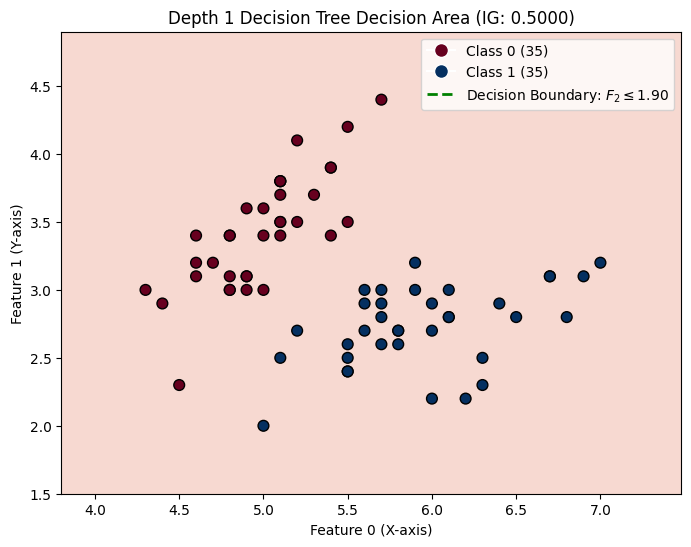

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D # For creating the dummy legend handles

# --- Assume previous code defines X_train, y_train, and scratch_dt ---
# --- And also assumes feature_a_idx=0 and feature_b_idx=1 for plotting ---

# Retrieve the learned parameters from your model
best_feature_idx_in_plot = scratch_dt.best_feature_idx
best_threshold = scratch_dt.best_threshold
left_pred = scratch_dt.left_node_prediction
right_pred = scratch_dt.right_node_prediction

# Select the two features for the plot
feature_a_idx = 0
feature_b_idx = 1
X_plot = X_train[:, [feature_a_idx, feature_b_idx]]

# 1. Define the plot boundaries and step size
x_min, x_max = X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5
y_min, y_max = X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# 2. Prepare the grid points for prediction
n_features_trained = X_train.shape[1]
X_dummy = np.zeros((xx.ravel().shape[0], n_features_trained))
X_dummy[:, feature_a_idx] = xx.ravel()
X_dummy[:, feature_b_idx] = yy.ravel()

# 3. Predict the class for every point in the grid
Z = scratch_dt.predict(X_dummy)
Z = Z.reshape(xx.shape)

# 4. Plot the decision regions and training data points
plt.figure(figsize=(8, 6))

# Plot the decision region using contourf
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)

# Plot the training points
scatter = plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y_train, edgecolors='k', cmap=plt.cm.RdBu, s=60)

# 5. Highlight the Decision Boundary (FIXED with raw strings 'r' for correct LaTeX)
if best_feature_idx_in_plot == feature_a_idx:
    # Vertical line (Decision on x-axis feature)
    plt.axvline(x=best_threshold, color='green', linestyle='--', linewidth=2, 
                label=r'Decision Boundary: $F_{' + str(feature_a_idx) + r'} \leq ' + f'{best_threshold:.2f}' + r'$') # Corrected with raw string
elif best_feature_idx_in_plot == feature_b_idx:
    # Horizontal line (Decision on y-axis feature)
    plt.axhline(y=best_threshold, color='green', linestyle='--', linewidth=2, 
                label=r'Decision Boundary: $F_{' + str(feature_b_idx) + r'} \leq ' + f'{best_threshold:.2f}' + r'$') # Corrected with raw string

# 6. Add a Legend (FIXED UserWarning by ensuring labels are visible)
# We manually create handles for the scatter plot classes
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label=f'Class {c} ({np.sum(y_train == c)})', 
           markerfacecolor=plt.cm.RdBu(c/1), markersize=10) 
    for c in np.unique(y_train)
]
# Add the decision boundary line handle
boundary_label = r'Decision Boundary: $F_{' + str(best_feature_idx_in_plot) + r'} \leq ' + f'{best_threshold:.2f}' + r'$'
boundary_handle = Line2D([0], [0], color='green', linestyle='--', linewidth=2, label=boundary_label)
legend_handles.append(boundary_handle)

plt.xlabel(f'Feature {feature_a_idx} (X-axis)')
plt.ylabel(f'Feature {feature_b_idx} (Y-axis)')
plt.title(f'Depth 1 Decision Tree Decision Area (IG: {scratch_dt.best_gain:.4f})')
plt.legend(handles=legend_handles) # Use the explicitly created handles
plt.show()

# The plot will show a single, clean line splitting the feature space into two regions.

In [ ]:
# [Problem 7] (Advance assignment) Creation of a decision tree classifier class with a depth of 2

In [22]:
import numpy as np

# Reutilizando as funções de impureza e ganho de informação (assumidas como definidas)
# def calculate_gini_impurity(y_node): ...
# def calculate_information_gain(y_parent, y_left, y_right): ...

class ScratchDecesionTreeClassifierDepth2():
    """
    Classificador de Árvore de Decisão Scratch com Profundidade 2 (CART).
    
    A estrutura da árvore é armazenada como um dicionário aninhado (self.tree_).
    """

    def __init__(self, verbose=False):
        self.verbose = verbose
        # self.tree_ armazenará toda a estrutura da árvore (até 5 divisões/nós de decisão).
        self.tree_ = {}
        self.root_prediction = None # Previsão de fallback

    def _get_leaf_prediction(self, y_node):
        """Determina a previsão da classe (voto majoritário) para um nó folha."""
        if len(y_node) == 0:
            return None
        unique, counts = np.unique(y_node, return_counts=True)
        return unique[np.argmax(counts)]

    def _find_best_split(self, X_node, y_node):
        """
        Encontra a melhor divisão (índice da característica, limite e ganho) para um dado nó.
        É a lógica do fit do Problema 3, adaptada para um nó genérico.
        """
        best_gain = -np.inf
        best_split = {'feature_idx': None, 'threshold': None, 
                      'gain': -np.inf, 'y_left': None, 'y_right': None}
        
        n_features = X_node.shape[1]

        for feature_idx in range(n_features):
            thresholds = np.unique(X_node[:, feature_idx])
            
            for threshold in thresholds:
                # 1. Dividir os dados
                mask_left = X_node[:, feature_idx] <= threshold
                y_left = y_node[mask_left]
                y_right = y_node[~mask_left]
                
                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                # 2. Calcular o Ganho de Informação
                current_gain = calculate_information_gain(y_node, y_left, y_right)

                # 3. Registrar a melhor divisão
                if current_gain > best_gain:
                    best_gain = current_gain
                    best_split.update({
                        'feature_idx': feature_idx,
                        'threshold': threshold,
                        'gain': current_gain,
                        'y_left': y_left,
                        'y_right': y_right
                    })
                    
        return best_split

    def fit(self, X, y):
        """
        Aprende o classificador de árvore de decisão com profundidade 2.
        
        X : ndarray, shape (n_samples, n_features)
            Características dos dados de treinamento
        y : ndarray, shape (n_samples,)
            Valores de resposta corretos dos dados de treinamento
        """
        self.root_prediction = self._get_leaf_prediction(y)
        
        # --- Profundidade 1: Divisão do Nó Raiz ---
        root_split = self._find_best_split(X, y)
        
        # Se não houver ganho, a árvore é apenas uma folha
        if root_split['gain'] <= 0 or root_split['feature_idx'] is None:
            self.tree_ = {'leaf': self.root_prediction}
            if self.verbose: print("A árvore é apenas um nó folha.")
            return

        # Armazenar a divisão da raiz (Nível 1)
        self.tree_ = {
            'feature_idx': root_split['feature_idx'],
            'threshold': root_split['threshold'],
            'left': {},
            'right': {}
        }
        
        # Mapear os dados para os nós filhos L e R
        mask_root_left = X[:, root_split['feature_idx']] <= root_split['threshold']
        X_L, y_L = X[mask_root_left], y[mask_root_left]
        X_R, y_R = X[~mask_root_left], y[~mask_root_left]

        if self.verbose:
            print(f"Nível 1 (Raiz) - Divisão em F{root_split['feature_idx']} <= {root_split['threshold']:.2f}, IG: {root_split['gain']:.4f}")

        # --- Profundidade 2: Subdivisão do Nó Esquerdo (L) ---
        
        # Se o nó já for puro ou muito pequeno, ele se torna uma folha
        if calculate_gini_impurity(y_L) == 0 or len(y_L) < 2:
            self.tree_['left'] = {'leaf': self._get_leaf_prediction(y_L)}
            if self.verbose: print(f"  Nó Esquerdo (L) se tornou folha. Predição: {self.tree_['left']['leaf']}")
        else:
            split_L = self._find_best_split(X_L, y_L)
            if split_L['gain'] > 0:
                self.tree_['left'] = {
                    'feature_idx': split_L['feature_idx'],
                    'threshold': split_L['threshold'],
                    'left': {'leaf': self._get_leaf_prediction(split_L['y_left'])}, # Folha LL
                    'right': {'leaf': self._get_leaf_prediction(split_L['y_right'])} # Folha LR
                }
                if self.verbose:
                    print(f"  Nível 2 (L) - Divisão em F{split_L['feature_idx']} <= {split_L['threshold']:.2f}, IG: {split_L['gain']:.4f}")
            else:
                self.tree_['left'] = {'leaf': self._get_leaf_prediction(y_L)}
                if self.verbose: print(f"  Nó Esquerdo (L) não pôde ser dividido (IG<=0). Predição: {self.tree_['left']['leaf']}")
                
        # --- Profundidade 2: Subdivisão do Nó Direito (R) ---

        # Se o nó já for puro ou muito pequeno, ele se torna uma folha
        if calculate_gini_impurity(y_R) == 0 or len(y_R) < 2:
            self.tree_['right'] = {'leaf': self._get_leaf_prediction(y_R)}
            if self.verbose: print(f"  Nó Direito (R) se tornou folha. Predição: {self.tree_['right']['leaf']}")
        else:
            split_R = self._find_best_split(X_R, y_R)
            if split_R['gain'] > 0:
                self.tree_['right'] = {
                    'feature_idx': split_R['feature_idx'],
                    'threshold': split_R['threshold'],
                    'left': {'leaf': self._get_leaf_prediction(split_R['y_left'])}, # Folha RL
                    'right': {'leaf': self._get_leaf_prediction(split_R['y_right'])} # Folha RR
                }
                if self.verbose:
                    print(f"  Nível 2 (R) - Divisão em F{split_R['feature_idx']} <= {split_R['threshold']:.2f}, IG: {split_R['gain']:.4f}")
            else:
                self.tree_['right'] = {'leaf': self._get_leaf_prediction(y_R)}
                if self.verbose: print(f"  Nó Direito (R) não pôde ser dividido (IG<=0). Predição: {self.tree_['right']['leaf']}")


    def _predict_sample(self, x, node):
        """
        Função recursiva para classificar uma única amostra (x) navegando pela árvore (node).
        """
        # Caso Base: Nó Folha
        if 'leaf' in node:
            return node['leaf']
        
        # Nó de Decisão
        feature = node['feature_idx']
        threshold = node['threshold']
        
        if x[feature] <= threshold:
            # Segue para o nó esquerdo
            return self._predict_sample(x, node['left'])
        else:
            # Segue para o nó direito
            return self._predict_sample(x, node['right'])


    def predict(self, X):
        """
        Estima o rótulo usando o classificador de árvore de decisão de profundidade 2.
        """
        if 'leaf' in self.tree_:
            # Caso em que a árvore é apenas uma folha (não houve divisão na raiz)
            return np.full(X.shape[0], self.root_prediction)
        
        predictions = np.empty(X.shape[0])
        
        # Iterar sobre cada amostra em X
        for i, x in enumerate(X):
            predictions[i] = self._predict_sample(x, self.tree_)
            
        return predictions

In [ ]:
#[Problem 8] (Advance assignment) Creation of decision tree classifier class with unlimited depth

In [23]:
import numpy as np

# Reutilizando as funções de impureza e ganho de informação (assumidas como definidas)
# def calculate_gini_impurity(y_node): ...
# def calculate_information_gain(y_parent, y_left, y_right): ...

class ScratchDecesionTreeClassifierDepthInf():
    """
    Classificador de Árvore de Decisão Scratch com Profundidade Ilimitada (CART).

    A árvore cresce até que todos os nós folha sejam puros (Gini=0) ou 
    não seja possível obter mais Ganho de Informação.
    
    Parâmetros
    ----------
    max_depth : int or None
        A profundidade máxima permitida para a árvore. Se None, cresce até a pureza.
    min_samples_split : int
        O número mínimo de amostras necessárias para dividir um nó.
    verbose : bool
        True para exibir o processo de aprendizado.
    """

    def __init__(self, max_depth=None, min_samples_split=2, verbose=False):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.verbose = verbose
        self.tree_ = None # Armazena a estrutura da árvore
        self.n_features_ = None
        self.n_classes_ = None

    def _get_leaf_prediction(self, y_node):
        """Determina a previsão da classe (voto majoritário) para um nó folha."""
        if len(y_node) == 0:
            return None
        unique, counts = np.unique(y_node, return_counts=True)
        return unique[np.argmax(counts)]

    def _find_best_split(self, X_node, y_node):
        """Encontra a melhor divisão (índice da característica, limite e ganho) para um dado nó."""
        best_gain = -np.inf
        best_split = {'feature_idx': None, 'threshold': None, 'gain': -np.inf, 'y_left': None, 'y_right': None}
        
        for feature_idx in range(self.n_features_):
            thresholds = np.unique(X_node[:, feature_idx])
            
            for threshold in thresholds:
                mask_left = X_node[:, feature_idx] <= threshold
                y_left = y_node[mask_left]
                y_right = y_node[~mask_left]
                
                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                current_gain = calculate_information_gain(y_node, y_left, y_right)

                if current_gain > best_gain:
                    best_gain = current_gain
                    best_split.update({
                        'feature_idx': feature_idx,
                        'threshold': threshold,
                        'gain': current_gain,
                        'y_left': y_left,
                        'y_right': y_right
                    })
                    
        return best_split

    def _build_tree(self, X_node, y_node, depth):
        """
        Função RECURSIVA para construir a árvore. 
        Retorna um nó de decisão (dicionário) ou um nó folha.
        """
        n_samples = len(y_node)
        
        # 1. Condições de Parada (Nó Folha)
        
        # A. Profundidade Máxima Atingida
        if self.max_depth is not None and depth >= self.max_depth:
            if self.verbose: print(f"{'  ' * depth} [Profundidade {depth}] Nó Folha (Max Depth). Predição: {self._get_leaf_prediction(y_node)}")
            return {'leaf': self._get_leaf_prediction(y_node)}
            
        # B. Pureza (Gini = 0)
        if calculate_gini_impurity(y_node) == 0:
            if self.verbose: print(f"{'  ' * depth} [Profundidade {depth}] Nó Folha (Puro). Predição: {self._get_leaf_prediction(y_node)}")
            return {'leaf': self._get_leaf_prediction(y_node)}
            
        # C. Amostras Mínimas para Divisão
        if n_samples < self.min_samples_split:
            if self.verbose: print(f"{'  ' * depth} [Profundidade {depth}] Nó Folha (Min Samples). Predição: {self._get_leaf_prediction(y_node)}")
            return {'leaf': self._get_leaf_prediction(y_node)}

        # 2. Encontrar a Melhor Divisão
        split = self._find_best_split(X_node, y_node)
        
        # D. Nenhum Ganho de Informação Positivo
        if split['gain'] <= 0 or split['feature_idx'] is None:
            if self.verbose: print(f"{'  ' * depth} [Profundidade {depth}] Nó Folha (No Gain). Predição: {self._get_leaf_prediction(y_node)}")
            return {'leaf': self._get_leaf_prediction(y_node)}

        if self.verbose:
            print(f"{'  ' * depth} [Profundidade {depth}] Divisão em F{split['feature_idx']} <= {split['threshold']:.2f}, IG: {split['gain']:.4f}")

        # 3. Preparar Sub-conjuntos de Dados
        mask_left = X_node[:, split['feature_idx']] <= split['threshold']
        X_L, y_L = X_node[mask_left], y_node[mask_left]
        X_R, y_R = X_node[~mask_left], y_node[~mask_left]

        # 4. Recursão
        left_subtree = self._build_tree(X_L, y_L, depth + 1)
        right_subtree = self._build_tree(X_R, y_R, depth + 1)
        
        # 5. Retornar o Nó de Decisão
        return {
            'feature_idx': split['feature_idx'],
            'threshold': split['threshold'],
            'left': left_subtree,
            'right': right_subtree
        }

    def fit(self, X, y):
        """Aprende o classificador de árvore de decisão."""
        self.n_features_ = X.shape[1]
        self.n_classes_ = len(np.unique(y))
        
        if self.verbose:
            print("--- Iniciando a Construção da Árvore de Decisão ---")
        
        # Inicia a construção da árvore a partir da profundidade 0
        self.tree_ = self._build_tree(X, y, depth=0)
        
        if self.verbose:
            print("--- Construção da Árvore Concluída ---")


    def _predict_sample(self, x, node):
        """Função recursiva para classificar uma única amostra (x)."""
        # Caso Base: Nó Folha
        if 'leaf' in node:
            return node['leaf']
        
        # Nó de Decisão
        feature = node['feature_idx']
        threshold = node['threshold']
        
        if x[feature] <= threshold:
            # Segue para o nó esquerdo
            return self._predict_sample(x, node['left'])
        else:
            # Segue para o nó direito
            return self._predict_sample(x, node['right'])


    def predict(self, X):
        """Estima o rótulo usando o classificador de árvore de decisão."""
        if self.tree_ is None:
             raise Exception("O modelo não foi treinado. Chame .fit() primeiro.")

        predictions = np.empty(X.shape[0])
        
        # Se a árvore for apenas uma folha (caso extremo de max_depth=0 ou IG=0 na raiz)
        if 'leaf' in self.tree_:
             return np.full(X.shape[0], self.tree_['leaf'])
        
        # Iterar sobre cada amostra em X e chamar a previsão recursiva
        for i, x in enumerate(X):
            predictions[i] = self._predict_sample(x, self.tree_)
            
        return predictions